In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import zipfile
# import os

# # zip_path = list(uploaded.keys())[0]  # اسم الملف المضغوط

# with zipfile.ZipFile("/content/drive/MyDrive/baby_cry_dataset/dataset.zip", 'r') as zip_ref:
#     zip_ref.extractall("dataset")  # هيعمل فولدر جديد اسمه dataset

In [ ]:
import os

extract_path = "/content/drive/MyDrive/baby_cry_dataset"

# استعراض الكلاسات
classes = os.listdir(extract_path)
print("Classes:", classes)

# استعراض الفايلات لكل كلاس
for cls in classes:
    class_folder = os.path.join(extract_path, cls)
    files = os.listdir(class_folder)
    print(f"\nClass: {cls} --> {len(files)} files")
    print(files[:10])

Classes: ['hungry', 'laugh', 'discomfort', 'belly_pain', 'burping']

Class: hungry --> 287 files
['04c3386b-e6bc-4bd0-8456-d46ae21a73fc-1435305829013-1.7-f-26-hu.wav', '035c6b30-a145-42b9-8d0f-445cd9003d2c-1435948197257-1.7-m-04-hu.wav', '045C5483-69E1-4BEC-B1D8-9286D174B9B2-1430102996-1.0-m-04-hu.wav', '0776b33b-c41a-4a2e-8b9c-f1c184be00c8-1437123838264-1.7-f-26-hu.wav', '03abcb8f-400a-47d8-ad82-7e4586cc06be-1431864192133-1.7-f-48-hu.wav', '0c8f14a9-6999-485b-97a2-913c1cbf099c-1430760394426-1.7-m-26-hu.wav', '0f257dac-7d6f-4575-9192-e3b4dcd3d4ef-1430185441581-1.7-f-26-hu.wav', '10A40438-09AA-4A21-83B4-8119F03F7A11-1430925172-1.0-f-26-hu.wav', '10A40438-09AA-4A21-83B4-8119F03F7A11-1430848070-1.0-f-26-hu.wav', '10A40438-09AA-4A21-83B4-8119F03F7A11-1430848034-1.0-f-26-hu.wav']

Class: laugh --> 108 files
['laugh_1.m4a_0.wav', 'laugh_1.m4a_1.wav', 'laugh_1.m4a_10.wav', 'laugh_1.m4a_21.wav', 'laugh_1.m4a_13.wav', 'laugh_1.m4a_17.wav', 'laugh_1.m4a_22.wav', 'laugh_1.m4a_20.wav', 'laugh_1.m4

In [ ]:
import os
output_path = "/content/dataset_wav_16k_mono"
os.makedirs(output_path, exist_ok=True)

classes = os.listdir(extract_path)

for cls in classes:
    class_folder = os.path.join(extract_path, cls)
    out_class_folder = os.path.join(output_path, cls)
    os.makedirs(out_class_folder, exist_ok=True)

    for file in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file)
        # نتحقق من الملفات الصوتية
        if os.path.isfile(file_path) and file.lower().endswith((".wav", ".mp3", ".m4a", ".3gp")):
            out_file = os.path.join(out_class_folder, os.path.splitext(file)[0] + ".wav")
            # تحويل مباشر باستخدام ffmpeg
            os.system(f"ffmpeg -y -i '{file_path}' -ac 1 -ar 16000 '{out_file}'")
        else:
            print(f"Skipped: {file_path} (not an audio file)")

In [ ]:
#1. توحيد طول الصوت
#2. remove noise
#3. data Augmentation
#4. feature extraction "mnsbic"
#5. توحيد حجم ال spec
# divide feature labels ...

In [ ]:
import os
import librosa

dataset_path = "/content/dataset_wav_16k_mono"

min_duration = 1.0  # أقل مدة للصوت بالثواني

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        file_path = os.path.join(class_path, file)

        try:
            # تحميل الصوت
            y, sr = librosa.load(file_path, sr=16000)

            # حساب مدة الصوت
            duration = librosa.get_duration(y=y, sr=sr)

            # حذف الملفات القصيرة
            if duration < min_duration:
                os.remove(file_path)
                print("Deleted short file:", file_path)

        except:
            # حذف الملفات التالفة
            os.remove(file_path)
            print("Deleted corrupted file:", file_path)

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np

dataset_path = "/content/dataset_wav_16k_mono"
output_path = "/content/dataset_fixed_6s"

os.makedirs(output_path, exist_ok=True)

target_sr = 16000
target_length = target_sr * 6  # 6 seconds

classes = os.listdir(dataset_path)

for cls in classes:
    class_folder = os.path.join(dataset_path, cls)
    out_class_folder = os.path.join(output_path, cls)
    os.makedirs(out_class_folder, exist_ok=True)

    for file in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file)

        if file.endswith(".wav"):

            signal, sr = librosa.load(file_path, sr=target_sr)

            # لو أطول من 6 ثواني
            if len(signal) > target_length:
                signal = signal[:target_length]

            # لو أقصر من 6 ثواني
            else:
                padding = target_length - len(signal)
                signal = np.pad(signal, (0, padding))

            out_file = os.path.join(out_class_folder, file)
            sf.write(out_file, signal, target_sr)

Noise Reduction

In [ ]:
!pip install noisereduce

In [ ]:
import os
import librosa
import soundfile as sf
import noisereduce as nr

In [ ]:
dataset_path = "/content/dataset_wav_16k_mono"
output_path = "/content/dataset_denoised"

os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, cls)
    out_class_folder = os.path.join(output_path, cls)

    os.makedirs(out_class_folder, exist_ok=True)

    for file in os.listdir(class_folder):

        file_path = os.path.join(class_folder, file)
        out_path = os.path.join(out_class_folder, file)

        try:
            # تحميل الصوت
            y, sr = librosa.load(file_path, sr=16000)

            # إزالة الضوضاء
            reduced_noise = nr.reduce_noise(
                y=y,
                sr=sr
            )

            # حفظ الصوت بعد التنظيف
            sf.write(out_path, reduced_noise, sr)

        except:
            print("Error:", file_path)

# ***Data Augmentation***

In [ ]:
# إضافة Noise
import numpy as np

def add_noise(y):
    noise = np.random.randn(len(y))
    return y + 0.005 * noise

In [ ]:
# تغيير السرعة (Time Stretch)
import librosa

def time_stretch(y):
    return librosa.effects.time_stretch(y, rate=0.9)

In [ ]:
# تغيير طبقة الصوت (Pitch Shift)
def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

In [ ]:
# تغيير مستوى الصوت
def change_volume(y):
    return y * 1.5

In [ ]:
import os

dataset_path = "/content/dataset_denoised"

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(folder, ":", len(files), "files")

hungry : 287 files
belly_pain : 116 files
burping : 95 files
laugh : 108 files
discomfort : 61 files


In [ ]:
# import os
# import librosa
# import soundfile as sf

# dataset_path = "/content/dataset_denoised"

# for root, dirs, files in os.walk(dataset_path):
#     for file in files:
#         if file.endswith(".wav"):

#             path = os.path.join(root, file)
#             y, sr = librosa.load(path, sr=16000)

#             # original
#             sf.write(path, y, sr)

#             # noise
#             y_noise = add_noise(y)
#             sf.write(path.replace(".wav","_noise.wav"), y_noise, sr)

#             # stretch
#             y_stretch = time_stretch(y)
#             sf.write(path.replace(".wav","_stretch.wav"), y_stretch, sr)

#             # pitch
#             y_pitch = pitch_shift(y, sr)
#             sf.write(path.replace(".wav","_pitch.wav"), y_pitch, sr)

In [ ]:
# import librosa
# import numpy as np
# import os
# import soundfile as sf
# import random

# input_path = "/content/dataset_denoised"
# output_path = "/content/augmented_dataset"

# os.makedirs(output_path, exist_ok=True)

# TARGET = 350  # عدد الملفات المطلوب لكل كلاس

# def augment_audio(y, sr):
#     aug_list = []

#     # 1. Noise
#     noise = y + 0.005 * np.random.randn(len(y))
#     aug_list.append(noise)

#     # 2. Pitch
#     pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
#     aug_list.append(pitch)

#     # 3. Speed
#     speed = librosa.effects.time_stretch(y, rate=1.2)
#     aug_list.append(speed)

#     return aug_list


# for cls in os.listdir(input_path):
#     class_folder = os.path.join(input_path, cls)
#     out_class_folder = os.path.join(output_path, cls)

#     os.makedirs(out_class_folder, exist_ok=True)

#     files = os.listdir(class_folder)

#     # نسخ الملفات الأصلية
#     for file in files:
#         src = os.path.join(class_folder, file)
#         dst = os.path.join(out_class_folder, file)
#         if os.path.isfile(src):
#             y, sr = librosa.load(src, sr=16000)
#             sf.write(dst, y, sr)

#     count = len(files)

#     # نعمل augmentation لحد ما نوصل TARGET
#     while count < TARGET:
#         file = random.choice(files)
#         file_path = os.path.join(class_folder, file)

#         y, sr = librosa.load(file_path, sr=16000)
#         augmented = augment_audio(y, sr)

#         for aug in augmented:
#             if count >= TARGET:
#                 break

#             out_file = os.path.join(out_class_folder, f"aug_{count}.wav")
#             sf.write(out_file, aug, sr)
#             count += 1

#     print(f"{cls} done: {count}")

In [ ]:
# import librosa
# import numpy as np
# import soundfile as sf
# import random

# input_path = "/content/dataset_denoised"
# TARGET = 400  # عدد الملفات لكل كلاس

# def augment_audio(y, sr):
#     choice = random.choice(["noise", "pitch", "speed"])

#     if choice == "noise":
#         noise_level = np.random.uniform(0.003, 0.02)
#         y = y + noise_level * np.random.randn(len(y))

#     elif choice == "pitch":
#         n_steps = np.random.randint(-4, 4)
#         y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

#     elif choice == "speed":
#         rate = np.random.uniform(0.8, 1.25)
#         y = librosa.effects.time_stretch(y, rate=rate)

#     return y

# # 🔁 اللوب
# for cls in os.listdir(input_path):
#     class_folder = os.path.join(input_path, cls)
#     out_class_folder = os.path.join(output_path, cls)

#     os.makedirs(out_class_folder, exist_ok=True)

#     files = os.listdir(class_folder)

#     # نسخ الملفات الأصلية
#     for file in files:
#         src = os.path.join(class_folder, file)
#         dst = os.path.join(out_class_folder, file)

#         if os.path.isfile(src):
#             y, sr = librosa.load(src, sr=16000)

#             # normalization
#             y = y / np.max(np.abs(y))

#             sf.write(dst, y, sr)

#     count = len(files)

#     # augmentation لحد TARGET
#     while count < TARGET:
#         file = random.choice(files)
#         file_path = os.path.join(class_folder, file)

#         y, sr = librosa.load(file_path, sr=16000)
#         y = y / np.max(np.abs(y))

#         aug = augment_audio(y, sr)

#         out_file = os.path.join(out_class_folder, f"aug_{count}.wav")
#         sf.write(out_file, aug, sr)

#         count += 1

#     print(f"{cls} done: {count}")

discomfort done: 400
scared done: 400
burping done: 400
hungry done: 428
belly_pain done: 400
tired done: 400
laugh done: 400


In [ ]:
import os
import librosa
import numpy as np
import soundfile as sf
import random
import shutil

input_path = "/content/dataset_denoised"
output_path = "/content/balanced_dataset"

TARGET = 200

# امسحي الفولدر القديم لو موجود
if os.path.exists(output_path):
    shutil.rmtree(output_path)

os.makedirs(output_path, exist_ok=True)

def augment_audio(y, sr):
    aug_list = []

    # Noise
    aug_list.append(y + 0.003 * np.random.randn(len(y)))

    # Pitch
    aug_list.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=2))

    # Speed
    aug_list.append(librosa.effects.time_stretch(y, rate=1.1))

    return aug_list

for cls in os.listdir(input_path):
    class_folder = os.path.join(input_path, cls)
    out_class_folder = os.path.join(output_path, cls)

    os.makedirs(out_class_folder, exist_ok=True)

    files = os.listdir(class_folder)

    # 🔻 لو الكلاس أكبر من TARGET → نعمل sampling
    if len(files) > TARGET:
        files = random.sample(files, TARGET)

    count = 0

    # نسخ الأصلي
    for file in files:
        src = os.path.join(class_folder, file)
        dst = os.path.join(out_class_folder, f"orig_{count}.wav")

        y, sr = librosa.load(src, sr=16000)
        sf.write(dst, y, sr)
        count += 1

    # 🔺 لو أقل من TARGET → نعمل augmentation
    while count < TARGET:
        file = random.choice(files)
        file_path = os.path.join(class_folder, file)

        y, sr = librosa.load(file_path, sr=16000)
        augmented = augment_audio(y, sr)

        for aug in augmented:
            if count >= TARGET:
                break

            out_file = os.path.join(out_class_folder, f"aug_{count}.wav")
            sf.write(out_file, aug, sr)
            count += 1

    print(f"{cls} done: {count}")

hungry done: 200
belly_pain done: 200
burping done: 200
laugh done: 200
discomfort done: 200


In [ ]:
import os

dataset_path = "/content/balanced_dataset"

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(folder, ":", len(files), "files")

hungry : 200 files
belly_pain : 200 files
burping : 200 files
laugh : 200 files
discomfort : 200 files


In [ ]:
# import os
# import librosa
# import numpy as np
# import soundfile as sf

# dataset_path = "/content/dataset_denoised"

# target_classes = ["scared", "laugh", "burping"]

# for cls in target_classes:

#     class_path = os.path.join(dataset_path, cls)

#     for file in os.listdir(class_path):

#         if file.endswith(".wav"):

#             path = os.path.join(class_path, file)

#             y, sr = librosa.load(path, sr=16000)

#             # Add noise
#             noise = y + 0.005 * np.random.randn(len(y))
#             sf.write(path.replace(".wav","_noise2.wav"), noise, sr)

#             # Pitch shift
#             pitch = librosa.effects.pitch_shift(y, sr=sr, n_steps=2)
#             sf.write(path.replace(".wav","_pitch2.wav"), pitch, sr)

#             # Time stretch
#             stretch = librosa.effects.time_stretch(y, rate=1.1)
#             sf.write(path.replace(".wav","_stretch2.wav"), stretch, sr)

In [ ]:
for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    if os.path.isdir(path):
        print(folder, len(os.listdir(path)))

hungry 200
belly_pain 200
burping 200
laugh 200
discomfort 200


# ***Mel Spectrogram***

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# import os
# import librosa
# import numpy as np
# import cv2

# dataset_path = "/content/dataset_denoised"
# output_path = "/content/melspectrograms"

# os.makedirs(output_path, exist_ok=True)

# for cls in os.listdir(dataset_path):

#     class_path = os.path.join(dataset_path, cls)

#     # نتأكد انه فولدر
#     if not os.path.isdir(class_path):
#         continue

#     out_class_path = os.path.join(output_path, cls)
#     os.makedirs(out_class_path, exist_ok=True)

#     files = os.listdir(class_path)

#     for i, file in enumerate(files):

#         if not file.endswith(".wav"):
#             continue

#         try:
#             file_path = os.path.join(class_path, file)

#             # load audio
#             y, sr = librosa.load(file_path, sr=16000)

#             # mel spectrogram
#             mel = librosa.feature.melspectrogram(
#                 y=y,
#                 sr=sr,
#                 n_mels=128,
#                 fmax=8000
#             )

#             mel_db = librosa.power_to_db(mel, ref=np.max)

#             # normalize للصورة
#             mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
#             mel_img = (mel_norm * 255).astype(np.uint8)

#             save_path = os.path.join(
#                 out_class_path,
#                 file.replace(".wav", ".png")
#             )

#             cv2.imwrite(save_path, mel_img)

#             # طباعة التقدم كل 100 ملف
#             if i % 100 == 0:
#                 print(f"{cls} : processed {i} files")

#         except Exception as e:
#             print("error in:", file)
#             print(e)

In [ ]:
import os
import librosa
import numpy as np
import cv2
import gc

dataset_path =  "/content/balanced_dataset"
output_path = "/content/melspectrograms"

BATCH_SIZE = 50

os.makedirs(output_path, exist_ok=True)

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(class_path):
        continue

    out_class_path = os.path.join(output_path, cls)
    os.makedirs(out_class_path, exist_ok=True)

    files = [f for f in os.listdir(class_path) if f.endswith(".wav")]

    print(f"Processing class: {cls} | total files: {len(files)}")

    for start in range(0, len(files), BATCH_SIZE):

        batch = files[start:start + BATCH_SIZE]

        for file in batch:
            try:
                file_path = os.path.join(class_path, file)

                # تحميل الصوت
                y, sr = librosa.load(file_path, sr=16000)

                # mel spectrogram
                mel = librosa.feature.melspectrogram(
                    y=y,
                    sr=sr,
                    n_mels=128,
                    fmax=8000,
                    fmin=0,
                )

                mel_db = librosa.power_to_db(mel, ref=np.max)

                # 🔴 تجنب القسمة على صفر
                if mel_db.max() == mel_db.min():
                    print("Skipped (constant):", file)
                    continue

                # normalization
                mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
                mel_img = (mel_norm * 255).astype(np.uint8)

                # 🔴 تأكد إن الصورة صالحة
                if mel_img is None or mel_img.size == 0:
                    print("Empty image:", file)
                    continue

                save_path = os.path.join(
                    out_class_path,
                    file.replace(".wav", ".png")
                )

                # 🔴 الحفظ
                success = cv2.imwrite(save_path, mel_img)

                if not success:
                    print("Failed to save:", save_path)
                else:
                    print("Saved:", save_path)

                # تنظيف الذاكرة
                del y, mel, mel_db, mel_norm, mel_img

            except Exception as e:
                print("Error in:", file)
                print(e)

        print(f"{cls}: processed {start + len(batch)}")

        gc.collect()

print("✅ Done!")

Processing class: hungry | total files: 200
Saved: /content/melspectrograms/hungry/orig_22.png
Saved: /content/melspectrograms/hungry/orig_47.png
Saved: /content/melspectrograms/hungry/orig_11.png
Saved: /content/melspectrograms/hungry/orig_186.png
Saved: /content/melspectrograms/hungry/orig_114.png
Saved: /content/melspectrograms/hungry/orig_153.png
Saved: /content/melspectrograms/hungry/orig_19.png
Saved: /content/melspectrograms/hungry/orig_183.png
Saved: /content/melspectrograms/hungry/orig_60.png
Saved: /content/melspectrograms/hungry/orig_18.png
Saved: /content/melspectrograms/hungry/orig_59.png
Saved: /content/melspectrograms/hungry/orig_74.png
Saved: /content/melspectrograms/hungry/orig_166.png
Saved: /content/melspectrograms/hungry/orig_1.png
Saved: /content/melspectrograms/hungry/orig_28.png
Saved: /content/melspectrograms/hungry/orig_90.png
Saved: /content/melspectrograms/hungry/orig_167.png
Saved: /content/melspectrograms/hungry/orig_133.png
Saved: /content/melspectrograms/

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
!ls /content

dataset		  dataset_fixed_6s	drive		 sample_data
dataset_denoised  dataset_wav_16k_mono	melspectrograms


Model


##focal loss function

In [ ]:
import tensorflow as tf
import numpy as np

class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for multi-class classification.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    Parameters:
    -----------
    gamma : float
        Focusing parameter. Higher values focus more on hard examples.
        Default: 2.0 (recommended in original paper)
    alpha : float
        Balancing parameter between 0 and 1.
        Default: 0.25
    """
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super(FocalLoss, self).__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # تأكد إن القيم في النطاق الصحيح لتجنب log(0)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # حساب cross-entropy العادية: -log(p_t)
        cross_entropy = -y_true * tf.math.log(y_pred)

        # حساب الـ focal weight: (1 - p_t)^gamma
        # p_t هي الاحتمالية للكلاس الصح
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        # تطبيق الـ focal weight
        focal_loss = self.alpha * focal_weight * cross_entropy

        # المجموع على كل الكلاسات والمتوسط على الـ batch
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


# ✅ اختبار الـ Focal Loss
focal_loss = FocalLoss(gamma=3.0, alpha=0.25)

# مثال: 3 samples, 7 classes
y_true_test = tf.one_hot([0, 1, 2], depth=7)
y_pred_test = tf.nn.softmax(tf.random.normal([3, 7]))

test_loss = focal_loss(y_true_test, y_pred_test)
print(f"✅ Focal Loss يعمل صح! Loss value: {test_loss.numpy():.4f}")


✅ Focal Loss يعمل صح! Loss value: 0.6650


In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import (
#     Input, Conv2D, MaxPooling2D, BatchNormalization,
#     Flatten, Dense, Dropout, GlobalAveragePooling2D
# )

# model = Sequential([
#     Input(shape=(224, 224, 3)),

#     # Block 1
#     Conv2D(32, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     Conv2D(32, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     MaxPooling2D(),
#     Dropout(0.25),

#     # Block 2
#     Conv2D(64, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     Conv2D(64, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     MaxPooling2D(),
#     Dropout(0.25),

#     # Block 3
#     Conv2D(128, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     Conv2D(128, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     MaxPooling2D(),
#     Dropout(0.3),

#     # Block 4
#     Conv2D(256, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     Conv2D(256, (3,3), activation='relu', padding='same'),
#     BatchNormalization(),
#     MaxPooling2D(),
#     Dropout(0.3),

#     # Head
#     GlobalAveragePooling2D(),
#     Dense(512, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.5),
#     Dense(256, activation='relu'),
#     Dropout(0.4),

#     Dense(7, activation='softmax')
# ])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     validation_split=0.2,

#     # rotation_range=10,
#     # zoom_range=0.1,
#     # width_shift_range=0.1,
#     # height_shift_range=0.1,
#     # horizontal_flip=True
# )

# train_data = train_datagen.flow_from_directory(
#     "/content/melspectrograms",
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='categorical',
#     subset='training'
# )

# val_data = train_datagen.flow_from_directory(
#     "/content/melspectrograms",
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='categorical',
#     subset='validation'
# )
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    # بدون أي augmentation هنا!
)

train_data = train_datagen.flow_from_directory(
    "/content/melspectrograms",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = val_datagen.flow_from_directory(
    "/content/melspectrograms",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 800 images belonging to 5 classes.
Found 200 images belonging to 5 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y = train_data.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
# model.compile(
#     optimizer='adam',
#    loss=FocalLoss(gamma=2.0, alpha=0.25),
#     metrics=['accuracy']
# )

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint

# checkpoint = ModelCheckpoint(
#     "best_model.keras",
#     monitor='val_loss',
#     save_best_only=True
# )

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=3,
#    restore_best_weights=True
# )

# model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=40,
#     callbacks=[early_stop, checkpoint],
#    class_weight=class_weights
# )

In [ ]:
# model.evaluate(val_data)

try

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # مجمد في البداية

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# المرحلة 1: تدريب الـ head بس (سريع)
print("=== Phase 1: Training head ===")
model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)

# المرحلة 2: Fine-tuning (فتح آخر 30 layer)
print("=== Phase 2: Fine-tuning ===")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop_ft, checkpoint],
    class_weight=class_weights
)

=== Phase 1: Training head ===
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.2837 - loss: 0.3388 - val_accuracy: 0.4600 - val_loss: 0.2089
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 537ms/step - accuracy: 0.3738 - loss: 0.2497 - val_accuracy: 0.5400 - val_loss: 0.1646
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 492ms/step - accuracy: 0.4487 - loss: 0.2097 - val_accuracy: 0.5650 - val_loss: 0.1517
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step - accuracy: 0.5050 - loss: 0.1875 - val_accuracy: 0.6050 - val_loss: 0.1449
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 486ms/step - accuracy: 0.5450 - loss: 0.1598 - val_accuracy: 0.5800 - val_loss: 0.1372
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step - accuracy: 0.5500 - loss: 0.1600 - val_accuracy: 0.6000 - val_loss: 0.1347
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 532ms/step - accuracy: 0.5700 - loss: 0.1543 - val_accuracy: 0.5950 - val_loss: 0.1292
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 496ms/step - accuracy: 0.58

In [ ]:
model.evaluate(val_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6550 - loss: 0.1073


[0.10727936029434204, 0.6549999713897705]

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint

# checkpoint = ModelCheckpoint(
#     "best_model.h5",
#     monitor='val_loss',
#     save_best_only=True
# )

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


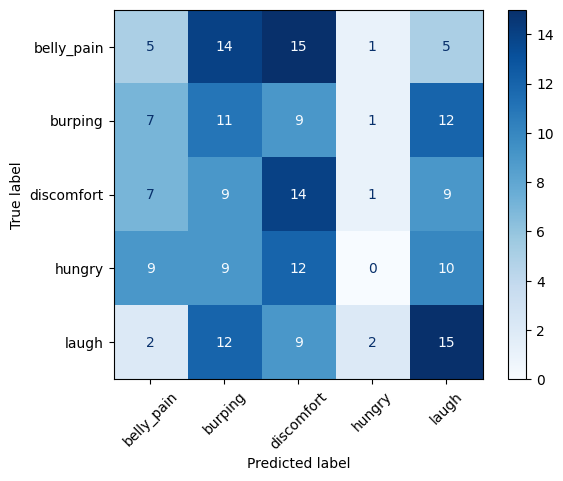

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# مهم جدًا
val_data.reset()

# predictions
y_pred = model.predict(val_data)
y_pred = np.argmax(y_pred, axis=1)

# labels الحقيقية
y_true = val_data.classes

# أسماء الكلاسات
class_names = list(val_data.class_indices.keys())

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()

transfere


In [ ]:
# from tensorflow.keras import layers
# base_model = tf.keras.applications.MobileNetV2(
#     input_shape=(224,224,3),
#     include_top=False,
#     weights='imagenet'
# )

# # هنا 👇
# base_model.trainable = False
# for layer in base_model.layers[:-30]:
#     layer.trainable = True

# x = base_model.output
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dense(128, activation='relu')(x)
# x = layers.Dropout(0.5)(x)

# output = layers.Dense(7, activation='softmax')(x)

# model = tf.keras.Model(inputs=base_model.input, outputs=output)

# # وبعدها compile 👇
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # مهم تقللي ال learning rate هنا
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

In [ ]:
# history = model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=10
# )